# Rectified Image Processing for Thermal Landscapes Project
### Makhohlola
 PB 6/23/22
 
Reads in rectified multiband thermal images from each site and looks for images that overlap with shapefiles of inside/outside the exclosures. Extracts metrics from thermal images for analysis.

##### Weird Things about Makhohlola
- The shapefile has 1 columns for treatments: 
    - "Treatment" which is either "Inside"/"Outside"

In [1]:
import rasterio as rio
import numpy as np
import geopandas as gpd
from pathlib import Path
import xarray as xr
import rioxarray as rioxr
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import seaborn as sns
from osgeo import gdal
# Thermal landscapes functions - 
# for calculating eveness between image regions,
# classifying veg type,
# & computing the proximity of pixels to a certain class of pixels (woody veg or ground)
from Functions_ThermalLandscapes import evenness, classifyVegType, computeProximityRaster

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

# Define inputs
img_dir = Path('/n/davies_lab/Lab/data/products/2020_01-02/MakhEP/raster/thermal/rectifiedimages')
shp_f = Path('./data/in/Polygons_AD_current/Makhohlola_polygon.shp')

# Set site/project string for output figures and stats
projstr = 'Makhohlola'

# Set figure directory for output figures
figdir = Path(f'./figs/final_120722/{projstr}/')
if not figdir.exists():
    figdir.mkdir()

# Set threshold of overlap tolerance btwn images
threshold = 0.25

# Set merged product dir for the project
# used for opening up CHM and other lidar data files
mergedprodstr = '2020-01-24_MakhohlolaEP'
mpdir = Path(f'/n/davies_lab/Lab/data/products_merged/{mergedprodstr}')


In [2]:
# Load extra inputs using user inputs

# Load shapefile
shp = gpd.read_file(shp_f)

# Reproject Shapefile to 32736 (if it's not already)
shp = shp.to_crs('EPSG:32736')

# Set hue order for plotting
exclosure_hues = ["Outside", "Inside"]

# Lidar data 
chmf = [t for t in mpdir.glob('./CHM/*025m*.tif')][0]

CHM = rioxr.open_rasterio(chmf,
                          parse_coordinates=True,
                          masked=True)

dtmf = [t for t in mpdir.glob('./DTM/*025m*.tif')][0]

DTM = rioxr.open_rasterio(dtmf,
                          parse_coordinates=True,
                          masked=True)

# Special for Makh - 
# rasters are in UTM31S (not 32736...) no idea why...
CHM.rio.write_crs(f'epsg:32736', inplace=True)
DTM.rio.write_crs(f'epsg:32736', inplace=True)

# Also, get PAI and Canopy Density Values from a diff folder
# Note, there is 1 set of pickle files per image file
# Note that they are netcdf files, 
# so you need to call the variable when you open it
# # https://rasterio.readthedocs.io/en/latest/topics/datasets.html
gridmetricdir = Path(f'/n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/{projstr}/grid_metrics')

# # # END USER INPUTS

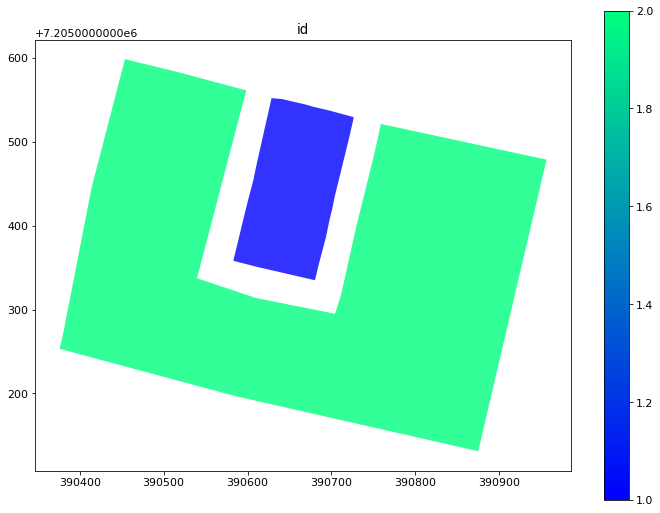

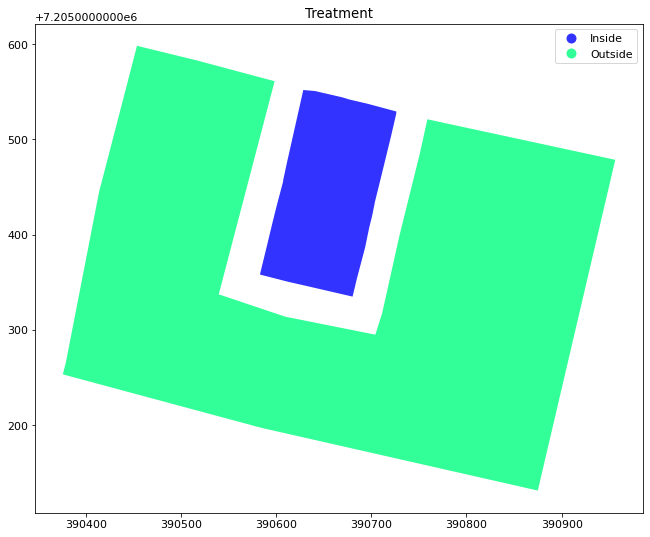

In [8]:
# Plot shapefile attributes
for c in shp.columns[0:-1]:
    if c == 'TopoPositi':
        shp.plot(column=c, legend=True, cmap='PuOr', alpha=0.8)
    else:
        shp.plot(column=c, legend=True, cmap='winter', alpha=0.8)
    plt.title(c)
    plt.savefig(f'{figdir}/ShapefileFeatures_{c}_{projstr}.jpg', dpi=300)

In [4]:

# # Function for classifying veg type by max height of pixel
# def classifyVeg_GGW(maxh, groundthreshold):
    
#     # tree_grass_shrub_bareground = []
#     if maxh <= groundthreshold:
    
#         # 'ground'
#         vegtype = int(1)
    
#     elif ((maxh > groundthreshold) & (maxh <= 1)):
        
#         # 'grass'
#         vegtype = int(2)
        
#     elif maxh > 1:
        
#         # 'woody'
#         vegtype = int(5)
        
#     else:
        
#         # noise/nan class
#         vegtype = int(-9999)
        
#     return vegtype

# # Define a simple evenness function
# # compares the difference in coverage 
# def evenness(x):
#     # Filter for non-zero values
#     X = x.loc[x>=0.01]
#     # if more than 2:
#     if len(X)>=2:
#         # test difference between the values
#         # This is the mean difference between the values
#         # Divided by the sum of the values
#         # 1 - is to make it an descending scale (higher values are better)
#         # even = 1 - (np.mean(np.abs(np.diff((X)))) / np.sum(X))
        
#         # Actually, screw that! Use coeff. of variation
#          # NOTE: -1* need to rescale so scale is descending
#         even = -1*(np.std(X)/np.mean(X))
#     else:
#         even = np.nan
#     return even


# def classifyVegType(h):
    
#     h = np.round(h, 5)
    
#     # "bare ground" pixels
#     if ((h > -0.03) & (h <= 0.05)):
#         veg = 'ground'
        
#     # grass
#     elif ((h > 0.05) & (h <= 0.5)):
#         veg = 'grass'
        
#     # shrub
#     elif ((h > 0.5) & (h <= 3)):
#         veg = 'shrub'
        
#     # tree (just using the top bracket to filter out noise points)
#     elif ((h > 3) & (h <= 20)):
#         veg = 'tree'
        
#     else:
#         veg = np.nan
        
#     return veg


# def computeProximityRaster(inf, of):
# # Distance to nearest ground from veg type (Ground, Grass, Woody) file
# # Copied and pasted from: 
# # https://github.com/marcelovilla/gdal-py-snippets/blob/master/scripts/compute_proximity.py
# # https://gdal.org/programs/gdal_proximity.html

#     ds = gdal.Open(inf, 0)
    
#     try:
        
#         band = ds.GetRasterBand(1)
#         gt = ds.GetGeoTransform()
#         sr = ds.GetProjection()
#         cols = ds.RasterXSize
#         rows = ds.RasterYSize

#         # create empty proximity raster
#         driver = gdal.GetDriverByName('GTiff')
#         out_ds = driver.Create(of, cols, rows, 1, gdal.GDT_Float32)
#         out_ds.SetGeoTransform(gt)
#         out_ds.SetProjection(sr)
#         out_band = out_ds.GetRasterBand(1)

#         # compute proximity
#         gdal.ComputeProximity(band, out_band, ['VALUES=1', 'DISTUNITS=PIXEL'])

#         print(f'Done with {Path(inf).name}.\n Output {of}.\n')
        
#     except Exception as e:
        
#         print(f'Issue with {Path(inf).name}.\n\t{e}\n')

In [5]:
woodyveg_outpath = Path(str(chmf.parent).replace('CHM', 'VegType'))
if not woodyveg_outpath.exists():
    woodyveg_outpath.mkdir()
woodyveg_f = outpath.joinpath(f'{projstr}_WoodyVeg_025m.tif')

WoodyVeg = CHM.copy()
WoodyVeg = WoodyVeg > 1
WoodyVeg.rio.to_raster(str(woodyveg_f), dtype="int8")

NameError: name 'outpath' is not defined

In [ ]:
WoodyVeg

In [ ]:
WoodyVeg = CHM.copy()

In [ ]:
# NOTE: where is strange - if condition is FALSE, then apply value, otherwise keep the value the same
WoodyVeg = WoodyVeg.where(((WoodyVeg < 1) & (WoodyVeg != -9999)), 1)

In [ ]:
WoodyVeg.plot.hist()

In [ ]:
WoodyVeg.plot()

In [ ]:
WoodyVeg.rio.to_raster(str(woodyveg_f))

In [ ]:
WoodyVeg = rioxr.open_rasterio(woodyveg_f,
                              parse_coordinates=True,
                              masked=True)

In [ ]:
WoodyVeg.plot()

In [ ]:

#https://github.com/OSGeo/gdal/blob/master/swig/python/gdal-utils/osgeo_utils/gdal_calc.py
# gdal.Calc(calc="A>1", A=str(chmf), A_band=1, outfile=str(outf), NoDataValue=-9999)

### Step 1: Filter imglist to maximize overlap with polygon treatments

In [6]:
# Make list of images to loop through
img_list = [i for i in img_dir.glob('*.tif')]

# for testing,reduce the list size
# img_list = img_list[0:100]

# Initialize list of img geometries
geom_list = []

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    # warnings.simplefilter("ignore")
    warnings.filterwarnings(action='once')
    
    # Loop through each image
    for f in img_list:

        # Load image
        img = rioxr.open_rasterio(f,
                                  parse_coordinates=True,
                                  masked=True)

        # Get boundary polygon of the img for below filters
        minx, miny, maxx, maxy = img.rio.bounds()

        x_list = [minx, maxx,
                  maxx, minx,
                  minx]
        y_list = [maxy, maxy,
                  miny, miny,
                  maxy]

        # Make Boundary in to a Shapely Polygon, and save in a list
        geom_list.append(Polygon(zip(x_list, y_list)))

    # Make a Geodataframe from the result
    img_gdf = gpd.GeoDataFrame({'img':img_list, 'geometry':geom_list}, geometry='geometry', crs='EPSG:32736')

    # Use the shapefile to get the area overlap of each of the images and each of the treatments
    for ID, T, feat in zip(shp.index, shp.Treatment, shp.geometry.values):
        
        temp = img_gdf.geometry.apply(feat.intersection)

        # Save absolute area of overlap (not as useful as the percent overlap)
        img_gdf[f'Area {T} {ID}'] = temp.area

        # Save percent overlap with feature
        img_gdf[f'Overlap {T} {ID}'] = temp.area / feat.area
        
        warnings.filterwarnings(action='once')

    # Filter for area coverage
    # Note: If you do this with percent coverages, as oppossed to absolute area
    # you get images that overlap 
    # Compute the sum overlapping area percentages
    img_gdf['Sum'] = img_gdf.filter(like='Overlap').apply(np.nansum, axis=1)
    
    # Filter for area coverage
    # Note: If you do this with percent coverages, as oppossed to absolute area
    # you get images that overlap 
    # Compute the sum overlapping area percentages
    img_gdf['Evenness'] = img_gdf.filter(like='Overlap').apply(lambda x: evenness(x), axis=1)

    # Sort and redindex values in descending order of evenness, then summed percent overlap
    img_gdf.sort_values(by=['Evenness','Sum'], axis=0, inplace=True, ascending=False, ignore_index=True)


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

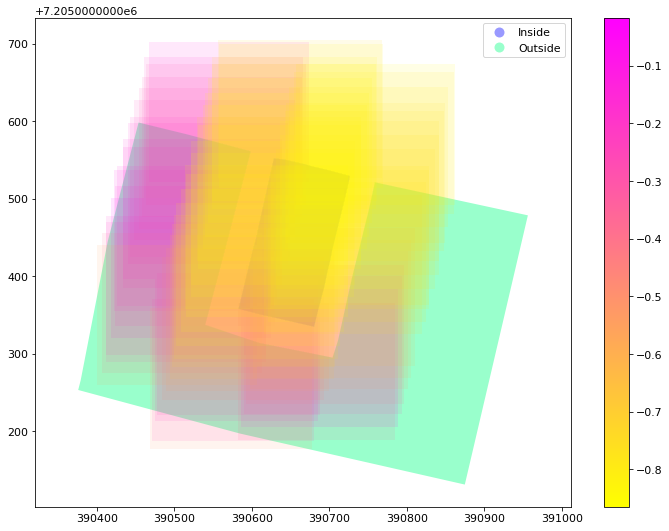

In [9]:
# Keep only the images that overlap multiple treatments
# Cutoff is that img has to overlap at least 100 m2 
# img_gdf['OverlapsTreatments'] = img_gdf.filter(like='Area').apply(lambda x: np.sum(x>100) > 1, axis=1)
# img_gdf_filter = img_gdf.loc[img_gdf['OverlapsTreatments']]

# Keep only the images that overlap multiple treatments
# (Cutoff is that img has to overlap at least 100 m2)
# Edited 7/5/2022 to only count images that overlap both inside and outside,
# Discluding polygons that overlap 2 polygons, but both polygons are the same treatment
img_gdf['OverlapsInside'] = img_gdf.filter(like='Area Inside').apply(lambda x: np.sum(x>1000) > 0, axis=1)
img_gdf['OverlapsOutside'] = img_gdf.filter(like='Area Outside').apply(lambda x: np.sum(x>1000) > 0, axis=1)
img_gdf_filter = img_gdf.loc[img_gdf['OverlapsInside'] & img_gdf['OverlapsOutside']]


fig, ax = plt.subplots()
# for img in pixel_dict['pixels_xr'][1]:
#     img.plot(ax=ax, alpha=0.3)

ax.axis('equal')
# clipbox.plot(ax=ax, alpha=0.3)
shp.plot(ax=ax, column='Treatment',
         legend=True, cmap='winter',
         alpha=0.4)
img_gdf_filter.plot(ax=ax, alpha=0.1, cmap='spring_r', column='Evenness', legend=True)

plt.savefig(f'{figdir}/ImageSelection_AllImagesbyEvenness_{projstr}.jpg', dpi=300)

### Step 2 - Choose a random set of images that do not overlap with each other

In [14]:
# Output dict of filenames, their bounding polygons, and their pixel xarrays 
# nested in a dict with the shapefile ids as keys
pixel_dict = {'imgf':{}.fromkeys(shp.index, []), 
              'pixels_xr':{}.fromkeys(shp.index, []),
              'x_xr':{}.fromkeys(shp.index, []),
              'y_xr':{}.fromkeys(shp.index, []),
              'z_xr':{}.fromkeys(shp.index, []),
              'h_xr':{}.fromkeys(shp.index, []),
              'cd_xr':{}.fromkeys(shp.index, []),
              'pai_xr':{}.fromkeys(shp.index, []),
              'Exclosure':{}.fromkeys(shp.index, []),
              'Polygon':{}.fromkeys(shp.index, []),
              'prox_xr':{}.fromkeys(shp.index, []),
              'proxwoody_xr':{}.fromkeys(shp.index, [])
              }

# Extra keys for other sites
# 'Topo':{}.fromkeys(shp.index, [])

# Edited 7/5/2022 - don't need pixels_xr in img_dict, since it's in pixel_dict
img_dict = {'imgf':[], 'boundary_poly':[]}

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# doesn't work for everything...
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Loop through each image
    for i, g in zip(img_gdf_filter.img.values,
                    img_gdf_filter.geometry.values):

        # Load image
        img = rioxr.open_rasterio(i,
                                  parse_coordinates=True,
                                  masked=True)

        # extract the temp band and convert to kelvin
        img_k = (img.sel(band=4)*0.04)

        # filter 0 degree C and below as nans
        img_k = img_k.where(img_k > 273.15)
        
        # Make a geodataframe to use below
        clipbox = gpd.GeoDataFrame(index=[0], crs='EPSG:32736', geometry=[g])

        # Check the image's overlap with all previous images that have been processed thusfar
        poly_gs = gpd.GeoSeries(data=img_dict['boundary_poly'], crs='EPSG:32736')
        poly_gs.intersects(g)

        # Get the areas of the intersections
        poly_gs_intersect = poly_gs.intersection(g)
        
        # Get the percentage overlap
        poly_overlapperc = poly_gs_intersect.area/g.area
        
        # If any of these values are >= threshold %, don't run the file
        # But if there's minimal overlap, pass it on 
        overlap_idx = np.any(poly_overlapperc >= threshold)
        
        if not(overlap_idx):
            
            img_dict['imgf'].append(str(i).split('/')[-1])
            
            # Save the shapely polygon
            img_dict['boundary_poly'].append(g)

            # loop through features in shapefile
            for ID, feat in zip(shp.index, shp.geometry.values):
                
                # Open netcdf file associated with this treatment
                # Get image name file i 
                name = str(i).split('/')[-1].split('.tif')[0]
                coverd2f = f'{gridmetricdir}/{name}/{name}_CoverD2.nc'
                PAId2f = f'{gridmetricdir}/{name}/{name}_FHPD2.nc'
                
                # Make proximity file from GGW tif 
                GGWf = f'{gridmetricdir}/{name}/{name}_vegtypeGGW.tif'
                proxf = f'{gridmetricdir}/{name}/{name}_ProximitytoGround.tif'

                # Compute and save a new proximity raster
                computeProximityRaster(inf=GGWf, of=proxf, pixvalue=1)
                
                PROX = rioxr.open_rasterio(proxf,
                                          parse_coordinates=True,
                                          masked=True)
                
                # Also, Make proximity to woody veg file
                woodyproxf = f'{gridmetricdir}/{name}/{name}_ProximitytoWoodyVeg.tif'

                # Compute and save a new proximity raster
                computeProximityRaster(inf=GGWf, of=woodyproxf, pixvalue=5)
                
                PROXwoody = rioxr.open_rasterio(woodyproxf,
                                                parse_coordinates=True,
                                                masked=True)

                # Open canopy density for this exclosure
                CD = rioxr.open_rasterio(coverd2f,
                                          parse_coordinates=True,
                                          masked=True)
                
                # Subset to Canopy Density at 5 cm
                CD = CD[CD.z==0.05]
                
                # Open PAI
                PAI = rioxr.open_rasterio(PAId2f,
                                          parse_coordinates=True,
                                          masked=True)

                # Only get PAI above 0.05 m
                PAI = PAI[PAI.z>0.05]
                
                # Sum to get total
                PAI_sum = PAI.sum(dim='z')
                
                # Save to raster for qgis
                PAI_sum.rio.to_raster(f'./data/out/raster/{name}_PAIabove5cm.tif')
                
                # Save attributes from images and shapefiles in nested dict
                pixel_dict['imgf'][ID].append(str(i).split('/')[-1])
                pixel_dict['Exclosure'][ID].append(shp.loc[ID].Treatment)
                # pixel_dict['Topo'][ID].append(shp.loc[ID].TopoPositi)
                pixel_dict['Polygon'][ID].append(feat)

                # Get the intersection, and clip your raster with it
                if clipbox.intersects(feat)[0]:
                    
                    pixels = img_k.rio.clip(clipbox.intersection(feat), drop=True)     

                    # # # Save lidar data in dict as well for later comparison
                    
                    # Use rio.reproject_match to cut out relevant area of the CHM, DTM, and CD
                    # and resample onto the same grid with same spatial res (0.5 m)
                    CHM_match = CHM.rio.reproject_match(pixels)
                    DTM_match = DTM.rio.reproject_match(pixels)
                    CD_match = CD.rio.reproject_match(pixels)
                    PAI_match = PAI_sum.rio.reproject_match(pixels)
                    PROX_match = PROX.rio.reproject_match(pixels)
                    PROXwoody_match = PROXwoody.rio.reproject_match(pixels)
                    
                    # Also, get the x,y coordinates of the pixels 
                    # (enables nearest tree analysis, etc., later)
                    x = pixels.x
                    y = pixels.y
                    
                    # Last, get the Clidar metric values for all the pixels
                    h = CHM_match.rio.clip(clipbox.intersection(feat), drop=True)
                    z = DTM_match.rio.clip(clipbox.intersection(feat), drop=True)
                    cd = CD_match.rio.clip(clipbox.intersection(feat), drop=True)
                    pai = PAI_match.rio.clip(clipbox.intersection(feat), drop=True)
                    prox = PROX_match.rio.clip(clipbox.intersection(feat), drop=True)
                    proxwoody = PROXwoody_match.rio.clip(clipbox.intersection(feat), drop=True)
                    
                else:
                    
                    pixels=[]
                    x=[]
                    y=[]
                    z=[]
                    h=[]
                    pai=[]
                    cd=[]
                    prox=[]
                    proxwoody=[]
                    n=0
                    
                # Store all pixels in the nested dictionary
                pixel_dict['pixels_xr'][ID].append(pixels)
                pixel_dict['x_xr'][ID].append(x)
                pixel_dict['y_xr'][ID].append(y)
                pixel_dict['z_xr'][ID].append(z)
                pixel_dict['h_xr'][ID].append(h)
                pixel_dict['cd_xr'][ID].append(cd)
                pixel_dict['pai_xr'][ID].append(pai)
                pixel_dict['prox_xr'][ID].append(prox)
                pixel_dict['proxwoody_xr'][ID].append(proxwoody)

Done with cam1-000-000108-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000108-0/cam1-000-000108-0_ProximitytoGround.tif.

Done with cam1-000-000108-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000108-0/cam1-000-000108-0_ProximitytoWoodyVeg.tif.

Done with cam1-000-000108-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000108-0/cam1-000-000108-0_ProximitytoGround.tif.

Done with cam1-000-000108-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000108-0/cam1-000-000108-0_ProximitytoWoodyVeg.tif.



Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


Done with cam1-000-000194-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000194-0/cam1-000-000194-0_ProximitytoGround.tif.

Done with cam1-000-000194-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000194-0/cam1-000-000194-0_ProximitytoWoodyVeg.tif.

Done with cam1-000-000194-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000194-0/cam1-000-000194-0_ProximitytoGround.tif.

Done with cam1-000-000194-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000194-0/cam1-000-000194-0_ProximitytoWoodyVeg.tif.



Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


Done with cam1-000-000095-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000095-0/cam1-000-000095-0_ProximitytoGround.tif.

Done with cam1-000-000095-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000095-0/cam1-000-000095-0_ProximitytoWoodyVeg.tif.

Done with cam1-000-000095-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000095-0/cam1-000-000095-0_ProximitytoGround.tif.

Done with cam1-000-000095-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000095-0/cam1-000-000095-0_ProximitytoWoodyVeg.tif.



Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

Done with cam1-000-000187-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000187-0/cam1-000-000187-0_ProximitytoGround.tif.

Done with cam1-000-000187-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000187-0/cam1-000-000187-0_ProximitytoWoodyVeg.tif.

Done with cam1-000-000187-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000187-0/cam1-000-000187-0_ProximitytoGround.tif.

Done with cam1-000-000187-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000187-0/cam1-000-000187-0_ProximitytoWoodyVeg.tif.



Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

Done with cam1-000-000178-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000178-0/cam1-000-000178-0_ProximitytoGround.tif.

Done with cam1-000-000178-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000178-0/cam1-000-000178-0_ProximitytoWoodyVeg.tif.

Done with cam1-000-000178-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000178-0/cam1-000-000178-0_ProximitytoGround.tif.

Done with cam1-000-000178-0_vegtypeGGW.tif.
 Output /n/davies_lab/Lab/LabLidarScripts/data/out/ThermalLandscapes/Makhohlola/grid_metrics/cam1-000-000178-0/cam1-000-000178-0_ProximitytoWoodyVeg.tif.



Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

In [15]:
# PROX.plot()

In [16]:
# PAI_sum.plot()

In [17]:
# TESTING - Distance to nearest ground
# using gdal to get proximity raster to ground pixels
# using GGW (ground grass woody veg type) map 
# https://gis.stackexchange.com/questions/417417/how-to-run-gdal-proximity-in-python-rather-than-command-line
# https://gdal.org/programs/gdal_proximity.html
# The below outlines how to use it
# https://github.com/marcelovilla/gdal-py-snippets/blob/master/scripts/compute_proximity.py
# Copied and pasted from it below
from osgeo import gdal
from pathlib import Path

# define funciton

def computeProximityRaster(inf, of, pixvalue=1):
# Distance to nearest ground from veg type (Ground, Grass, Woody) file
# pixvalue = value of the pixel to compute distance to
# Copied and pasted from: 
# https://github.com/marcelovilla/gdal-py-snippets/blob/master/scripts/compute_proximity.py
# https://gdal.org/programs/gdal_proximity.html

    ds = gdal.Open(inf, 0)
    
    try:
        
        band = ds.GetRasterBand(1)
        gt = ds.GetGeoTransform()
        sr = ds.GetProjection()
        cols = ds.RasterXSize
        rows = ds.RasterYSize

        # create empty proximity raster
        driver = gdal.GetDriverByName('GTiff')
        out_ds = driver.Create(of, cols, rows, 1, gdal.GDT_Float32)
        out_ds.SetGeoTransform(gt)
        out_ds.SetProjection(sr)
        out_band = out_ds.GetRasterBand(1)

        # compute proximity
        gdal.ComputeProximity(band, out_band, [f'VALUES={pixvalue}', 'DISTUNITS=PIXEL', 'NODATA=-9999'])

        print(f'Done with {Path(inf).name}.\n Output {of}.\n')
        
    except Exception as e:
        
        print(f'Issue with {Path(inf).name}.\n\t{e}\n')

# # Loop through each image
# for i, g in zip(img_gdf_filter.img.values,
#                 img_gdf_filter.geometry.values):
    
#     # Get image name file i 
#     name = str(i).split('/')[-1].split('.tif')[0]
#     GGWf = f'{gridmetricdir}/{name}/{name}_vegtypeGGW.tif'
#     outf = f'{gridmetricdir}/{name}/{name}_ProximitytoGround.tif'
    
#     # Compute and save a new proximity raster
#     computeProximityRaster(inf=GGWf, of=outf)
    

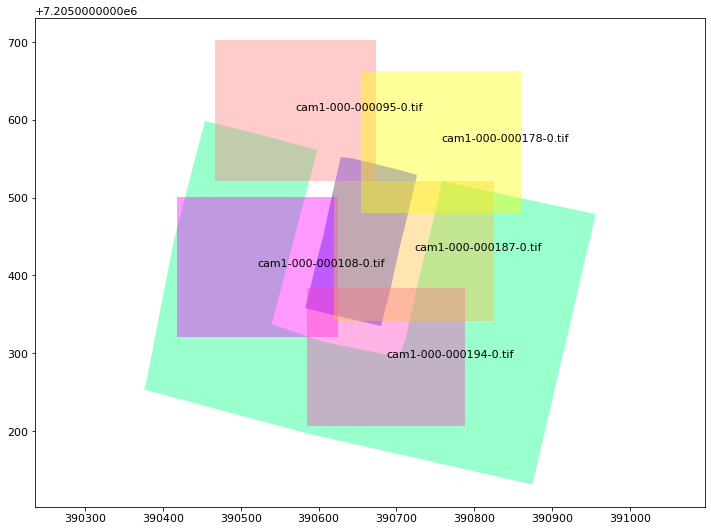

In [19]:
# Plot when done to get a sense of images and locations

# NOTE: need to re-subset polygs with dropflag
poly_gs = gpd.GeoSeries(data=img_dict['boundary_poly'], crs='EPSG:32736')

fig, ax = plt.subplots()
# for img in pixel_dict['pixels_xr'][1]:
#     img.plot(ax=ax, alpha=0.3)

ax.axis('equal')
# clipbox.plot(ax=ax, alpha=0.3)
shp.plot(ax=ax, cmap='winter', alpha=0.4, column='Treatment')
poly_gs.plot(ax=ax, alpha=0.4, cmap='spring')

labels = [str(s) for s in np.array(img_dict['imgf'])]

for cx, cy, t in zip(poly_gs.centroid.x.values, poly_gs.centroid.y.values, labels):
    ax.text(cx, cy, t)
    
fig.savefig(f'{figdir}/FinalImageOverlap_{projstr}.png', dpi=300)

In [60]:
# Initialize df list for loop
df_list = []

# For each polygon treatment in the shapefile
for ID in shp.index:
    
    # For each image
    for i, img in enumerate(pixel_dict['imgf'][ID]):
        
        df = pd.DataFrame()
        
        # If there are pixels for this treatment (it's NOT an empty list)
        if len(pixel_dict['pixels_xr'][ID][i])!=0:
            
            # Make an exploded dataframe, with each pixel noted by it's treatment, topo, and imgfile
            df = pd.DataFrame({'Temperature':pixel_dict['pixels_xr'][ID][i].data.flatten() - 273.15,
                               'Height':pixel_dict['h_xr'][ID][i].data.flatten(),                         
                               'Elevation':pixel_dict['z_xr'][ID][i].data.flatten(),
                               'Exclosure':pixel_dict['Exclosure'][ID][i],
                               'CanopyDensity':pixel_dict['cd_xr'][ID][i].data.flatten(),
                               'PAI':pixel_dict['pai_xr'][ID][i].data.flatten(),
                               'ProximitytoGround':pixel_dict['prox_xr'][ID][i].data.flatten(),
                               'ProximitytoWoodyVeg':pixel_dict['proxwoody_xr'][ID][i].data.flatten(),
                               'imgf':img})

            # Drop na rows
            df.dropna(axis=0, how='any', inplace=True)
            
            # store DataFrame in list
            df_list.append(df.copy(deep=True))

# Concat all the dfs to make a full df 
df_pixels = pd.concat(df_list, ignore_index=True, sort=False)

In [61]:
# Add Vegtype, and save outputs as pickles

# # using list comprehension
vs = [classifyVegType(h) for h in df_pixels.Height]
df_pixels['VegType'] = vs

# Also, add canopy density as a percent
df_pixels['CanopyDensityPercent'] = df_pixels.CanopyDensity*100

# Save output as pickle obj file
df_pixels.to_pickle(f'./data/out/pixelpickles/{projstr}_pixels.obj')

In [62]:
# Set the seaborn plot theme to default
# incorporates grey grid into background of figures
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(font_scale=1.35, style="ticks", rc=custom_params)

## Print Statistics and Plot

In [63]:
nFull = df_pixels.loc[df_pixels.Exclosure=='Inside'].shape[0]
nOpen = df_pixels.loc[df_pixels.Exclosure=='Outside'].shape[0]
print(f'Open: {nOpen}, Full: {nFull}')

Open: 1381788, Full: 502468


In [64]:
df_stats = df_pixels.groupby(['imgf', 'Exclosure']).describe()
df_stats.to_csv(f'./data/out/{projstr}_stats.csv')

In [65]:
df_pixels.groupby(['imgf', 'Exclosure']).mean()

Temperature    Height   Elevation  \
imgf                  Exclosure                                      
cam1-000-000095-0.tif Inside       33.843357  1.095160  248.653015   
                      Outside      34.547966  0.321793  250.084854   
cam1-000-000108-0.tif Inside       33.754131  0.959859  247.757065   
                      Outside      34.833702  0.387438  249.044769   
cam1-000-000178-0.tif Inside       33.776661  0.960292  247.968460   
                      Outside      33.946331  0.392780  246.337067   
cam1-000-000187-0.tif Inside       33.483143  0.799680  247.503235   
                      Outside      33.541073  0.400005  245.764572   
cam1-000-000194-0.tif Inside       33.164211  1.188322  246.943375   
                      Outside      33.802414  0.445973  245.285568   

                                 CanopyDensity       PAI  ProximitytoGround  \
imgf                  Exclosure                                               
cam1-000-000095-0.tif Inside          0.846171  0.285256          64.207069   
                      Outside         0.855364  0.081259          85.401344   
cam1-000-000108-0.tif Inside          0.924368  0.480240       -9999.000000   
                      Outside         0.900922  0.138285       -9999.000000   
cam1-000-000178-0.tif Inside          0.905502  0.565660          90.767105   
                      Outside         0.889046  0.177432         103.479958   
cam1-000-000187-0.tif Inside          0.926039  0.459560         142.419266   
                      Outside         0.915212  0.155847         141.172485   
cam1-000-000194-0.tif Inside          0.931596  0.542517       -9999.000000   
                      Outside         0.914571  0.165399       -9999.000000   

                                 ProximitytoWoodyVeg  CanopyDensityPercent  
imgf                  Exclosure                                             
cam1-000-000095-0.tif Inside                2.927007             84.617127  
                      Outside               5.617198             85.536437  
cam1-000-000108-0.tif Inside                2.246151             92.436768  
                      Outside               5.874261             90.092205  
cam1-000-000178-0.tif Inside                1.962149             90.550167  
                      Outside               4.377751             88.904607  
cam1-000-000187-0.tif Inside                2.388140             92.603940  
                      Outside               5.247690             91.521235  
cam1-000-000194-0.tif Inside                2.056124             93.159641  
                      Outside               4.917001             91.457126

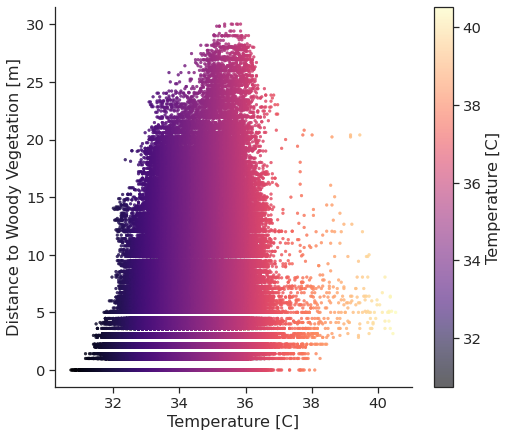

In [66]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

# df_pixels_prox = df_pixels.loc[df_pixels.ProximitytoWoodyVeg >= 0]

a = ax.scatter(x=df_pixels.Temperature,
               y=df_pixels.ProximitytoWoodyVeg,
               c=df_pixels.Temperature,
               alpha=0.6, cmap='magma', s=10, marker='o',
               edgecolors='none')

fig.colorbar(a, label='Temperature [C]')

# ax.set_ylim(-0.1, 10)

# ax.set_xlim(33, 55)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Distance to Woody Vegetation [m]')

fig.savefig(f'{figdir}/ScatterPlot_TempxProximitytoWoodyVeg_{projstr}.jpg', dpi=300)

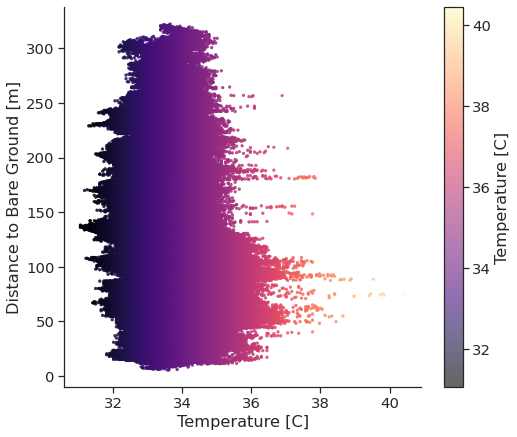

In [51]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

df_pixels_prox = df_pixels.loc[df_pixels.ProximitytoGround >= 0]

a = ax.scatter(x=df_pixels_prox.Temperature,
               y=df_pixels_prox.ProximitytoGround,
               c=df_pixels_prox.Temperature,
               alpha=0.6, cmap='magma', s=10, marker='o',
               edgecolors='none')

fig.colorbar(a, label='Temperature [C]')

# ax.set_ylim(-0.1, 10)

# ax.set_xlim(33, 55)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Distance to Bare Ground [m]')

fig.savefig(f'{figdir}/ScatterPlot_TempxProximitytoGround_{projstr}.jpg', dpi=300)

In [ ]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

df_pixels_0p1m = df_pixels.loc[df_pixels.Height >= 0.1]

a = ax.scatter(x=df_pixels_0p1m.Temperature,
               y=df_pixels_0p1m.PAI,
               c=df_pixels_0p1m.Temperature,
               alpha=0.6, cmap='magma', s=10, marker='o',
               edgecolors='none')

fig.colorbar(a, label='Temperature [C]')

ax.set_ylim(-0.1, 10)

# ax.set_xlim(33, 55)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Plant Area Index')

fig.savefig(f'{figdir}/ScatterPlot_TempxPAI_{projstr}.jpg', dpi=300)

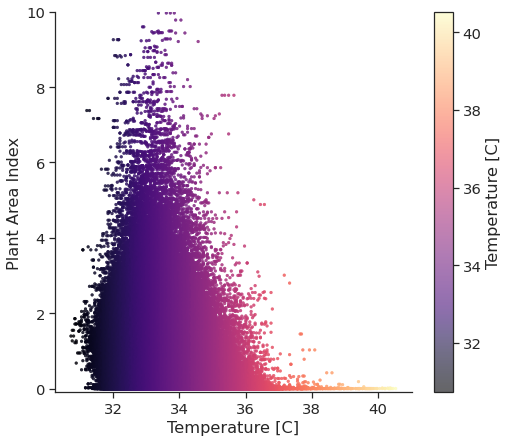

In [27]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

df_pixels_0p1m = df_pixels.loc[df_pixels.Height >= 0.1]

a = ax.scatter(x=df_pixels_0p1m.Temperature,
               y=df_pixels_0p1m.PAI,
               c=df_pixels_0p1m.Temperature,
               alpha=0.6, cmap='magma', s=10, marker='o',
               edgecolors='none')

fig.colorbar(a, label='Temperature [C]')

ax.set_ylim(-0.1, 10)

# ax.set_xlim(33, 55)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Plant Area Index')

fig.savefig(f'{figdir}/ScatterPlot_TempxPAI_{projstr}.jpg', dpi=300)

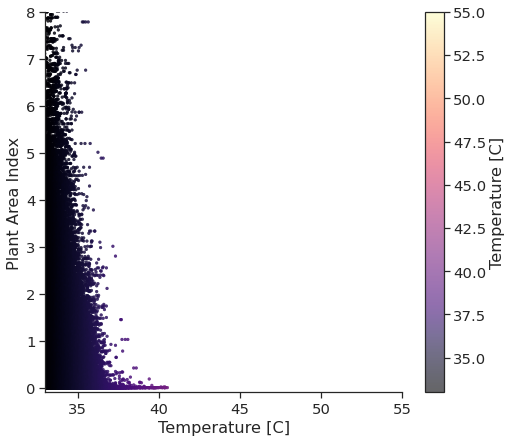

In [28]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

df_pixels_0p1m = df_pixels.loc[df_pixels.Height >= 0.1]

a = ax.scatter(x=df_pixels_0p1m.Temperature,
               y=df_pixels_0p1m.PAI,
               c=df_pixels_0p1m.Temperature,
               alpha=0.6, cmap='magma', s=10, marker='o',
               edgecolors='none',
               vmin=33,
               vmax=55)

fig.colorbar(a, label='Temperature [C]')

ax.set_ylim(-0.1, 8)

ax.set_xlim(33, 55)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Plant Area Index')

fig.savefig(f'{figdir}/ScatterPlot_TempxPAI_{projstr}_XYlimited.jpg', dpi=300)

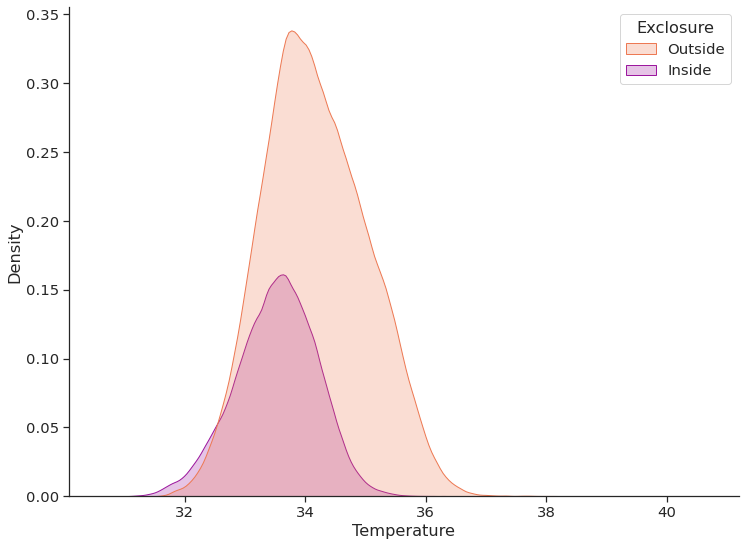

In [27]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels, x='Temperature', hue='Exclosure', ax=ax,
            palette='plasma_r', fill=True, hue_order=exclosure_hues)
fig.savefig(f'{figdir}/KDEplot_Exclosure_{projstr}.png', dpi=300)

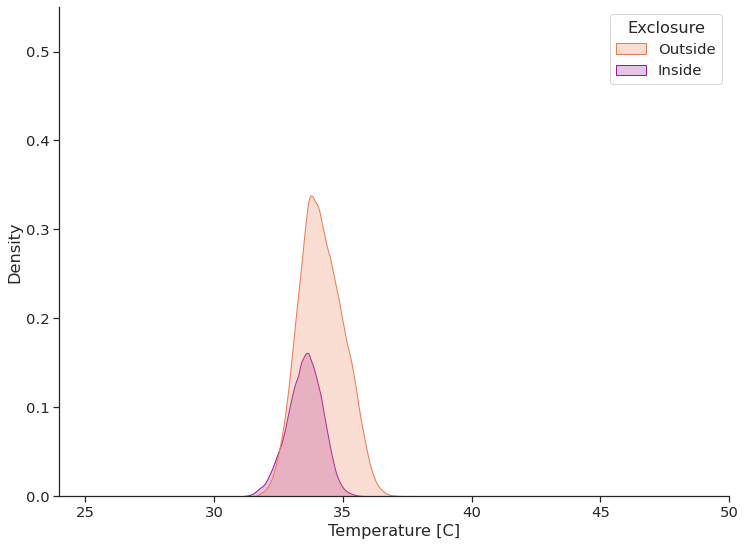

In [28]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels, x='Temperature', hue='Exclosure', ax=ax, palette='plasma_r',
            fill=True, hue_order=exclosure_hues)

ax.set_xlim(24, 50)
ax.set_ylim(0, 0.55)
ax.set_xlabel('Temperature [C]')

fig.savefig(f'{figdir}/KDEplot_Exclosure_Xlimited_{projstr}.jpg',
            dpi=300)

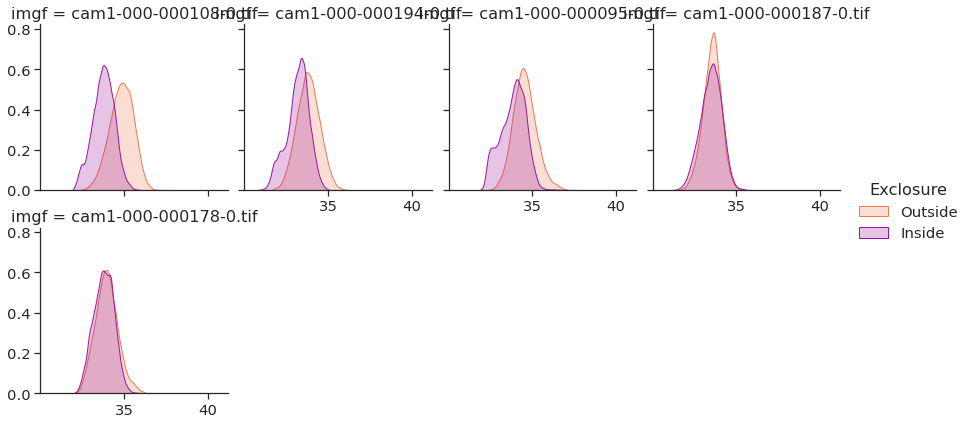

In [29]:
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams.update({'font.size': 10})

# Use to dataframe to plot KDE plots in a facetgrid
FG = sns.FacetGrid(data=df_pixels, col='imgf', hue='Exclosure', palette='plasma_r',
                   col_wrap=4, hue_order=exclosure_hues)
FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
FG.add_legend()
FG.tight_layout()
# ax.legend()


FG.savefig(f'{figdir}/KDEPlot_Exclosure_FacetGrid_{projstr}_byimgpe.png', dpi=300)